# **Projeto de análise financeira em Python**

(https://github.com/paulofernandoleitefilho/projetoAnaliseFinanceira)

Paulo Fernando Leite Filho



## **Baixando o dataset do Google Drive**

# **Script para criação do dataset:**

1 - Como objetivo para criar o dataset devem ser atendidos os seguintes pontos:

Criar o arquivo transacoes.csv manualmente antes de executar o notebook. O arquivo deve seguir a estrutura de colunas acima, conter pelo menos 15 registros válidos distribuídos em 3 ou mais meses, 5 registros inválidos para testar a validação e pelo menos 2 transações com valor acima de R$ 10.000,00. Consulte a célula de instruções no início do notebook para mais detalhes.

2 - Foi utilizando o exemplo de dados abaixo na criação do dataset transacoes:

id,data,cliente_id,tipo,valor,descricao,categoria
1,2026-01-05,CLI001,credito,3500.00,Salário janeiro,salario
2,2026-01-12,CLI002,debito,180.50,Supermercado,compra
3,2026-01-20,CLI001,debito,abc,Erro de sistema,compra
4,2026-02-03,,debito,200.00,Sem cliente,transferencia
5,2026-02-14,CLI003,credito,15000.00,Transferência suspeita,transferencia
6,2026-02-18,CLI002,debito,320.00,Conta de luz,conta
7,2026-03-01,CLI001,credito,3500.00,Salário março,salario
8,2026-03-10,CLI003,debito,99.90,Streaming,assinatura

3 - Foi utulizado exemplo de dados no prompt abaixo no ChatGPT para criar o dataset transacoes e exportá-lo para .csv:

" Crie um dataset utilizando o exemplo de dados [exemplo de dados] e conforme a estrutura infomrada nas colunas, conter pelo menos 15 registros válidos distribuídos em 3 ou mais meses, 5 registros inválidos para testar a validação e pelo menos 2 transações com valor acima de R$ 10.000,00

exemplo de dados = id,data,cliente_id,tipo,valor,descricao,categoria
1,2026-01-05,CLI001,credito,3500.00,Salário janeiro,salario
2,2026-01-12,CLI002,debito,180.50,Supermercado,compra
3,2026-01-20,CLI001,debito,abc,Erro de sistema,compra
4,2026-02-03,,debito,200.00,Sem cliente,transferencia
5,2026-02-14,CLI003,credito,15000.00,Transferência suspeita,transferencia
6,2026-02-18,CLI002,debito,320.00,Conta de luz,conta
7,2026-03-01,CLI001,credito,3500.00,Salário março,salario
8,2026-03-10,CLI003,debito,99.90,Streaming,assinatura

Como resposta, organize o dataset em uma planilha transacoes.csv para download"

Dataset armazenado no google Drive (https://drive.google.com/file/d/1K-YW9K71Nmyv-mORjjINOfwTy52c1FB5/view?usp=sharing)



**Bibliotecas Python utlizadas no projeto**

In [53]:
!pip install matplotlib pandas # Item opcional

import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt

import csv
import numpy as np
from datetime import datetime
from google.colab import drive

import csv
import json
import os
from datetime import datetime

print("Libraries OK !!")

Libraries OK !!


**Apos exportar o dataset para o Google Drive, acessá-lo**

In [54]:
# Mount Google Drive
drive.mount('/content/drive')

# Define the path to the CSV file
file_path = '/content/drive/MyDrive/Datasets/Projeto/transacoes.csv'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Leitura do arquivo CSV com módulo nativo e Validação e limpeza dos dados**

In [55]:
# Realiza a leitura do arquivo CSV diretamente para dfBdD
dfBdD = pd.read_csv(file_path, sep=';')

# Verifique as colunas e os tipos de dados de dfBdD para confirmar o carregamento correto
print("Informações do DataFrame dfBdD:")
display(dfBdD.info())

print("\nPrimeiras 5 linhas de dfBdD após verificação de colunas:")
display(dfBdD.head())

# Removido todo o código relacionado à leitura nativa do CSV e validação inicial
# que estava presente na célula KWZre1RYYNM3 original para evitar duplicação
# e garantir que dfBdD é a única fonte de dados brutos para processamento.

Informações do DataFrame dfBdD:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          20 non-null     int64 
 1   data        20 non-null     object
 2   cliente_id  19 non-null     object
 3   tipo        20 non-null     object
 4   valor       20 non-null     object
 5   descricao   20 non-null     object
 6   categoria   20 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.2+ KB


None


Primeiras 5 linhas de dfBdD após verificação de colunas:


,id,data,cliente_id,tipo,valor,descricao,categoria
0,1,05/01/2026,CLI001,credito,3500.00,Salário janeiro,salario
1,2,12/01/2026,CLI002,debito,180.50,Supermercado,compra
2,3,20/01/2026,CLI001,debito,850.00,Farmácia,saude
3,4,03/02/2026,CLI004,debito,200.00,Transferência entre contas,transferencia
4,5,14/02/2026,CLI003,credito,15000.00,Transferência empresarial,transferencia


In [56]:
print("Informações do DataFrame dfBdD:")
display(dfBdD.info())

print("Primeiras 5 linhas de dfBdD após verificação de colunas:")
display(dfBdD.head())

Informações do DataFrame dfBdD:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          20 non-null     int64 
 1   data        20 non-null     object
 2   cliente_id  19 non-null     object
 3   tipo        20 non-null     object
 4   valor       20 non-null     object
 5   descricao   20 non-null     object
 6   categoria   20 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.2+ KB


None

Primeiras 5 linhas de dfBdD após verificação de colunas:


,id,data,cliente_id,tipo,valor,descricao,categoria
0,1,05/01/2026,CLI001,credito,3500.00,Salário janeiro,salario
1,2,12/01/2026,CLI002,debito,180.50,Supermercado,compra
2,3,20/01/2026,CLI001,debito,850.00,Farmácia,saude
3,4,03/02/2026,CLI004,debito,200.00,Transferência entre contas,transferencia
4,5,14/02/2026,CLI003,credito,15000.00,Transferência empresarial,transferencia


**Organização do código em funções**

In [58]:
# --- CONFIGURAÇÃO DE CAMINHOS ---
FILE_PATH = '/content/drive/MyDrive/Datasets/Projeto/transacoes.csv'
JSON_OUTPUT_PATH = 'relatorio.json'


# --- DEFINIÇÃO DAS FUNÇÕES ---

def ler_transacoes(caminho_csv):
    """
    Responsabilidade: Ler o CSV nativamente e retornar uma lista de transações brutas.
    """
    transacoes_brutas = []
    try:
        with open(caminho_csv, mode='r', encoding='utf-8') as arquivo:
            leitor = csv.DictReader(arquivo)
            for linha in leitor:
                transacoes_brutas.append(linha)
    except FileNotFoundError:
        print(f"Erro: O arquivo no caminho '{caminho_csv}' não foi encontrado.")
    return transacoes_brutas


def validar_transacao(linha):
    """
    Responsabilidade: Valida uma única linha (dicionário).
    Retorna o registro limpo/tipado se válido, ou None se for inválido.
    """
    # 1. Validação do ID (Não vazio e numérico)
    id_val = linha.get('id', '').strip()
    if not id_val or not id_val.isdigit():
        return None

    # 2. Validação do cliente_id (Não vazio)
    cliente_id = linha.get('cliente_id', '').strip()
    if not cliente_id:
        return None

    # 3. Validação da Data (Formato estrito AAAA-MM-DD)
    data_val = linha.get('data', '').strip()
    try:
        datetime.strptime(data_val, '%Y-%m-%d')
    except ValueError:
        return None

    # 4. Validação do Tipo ('credito' ou 'debito')
    tipo_val = linha.get('tipo', '').strip().lower()
    if tipo_val not in ['credito', 'debito']:
        return None

    # 5. Validação do Valor (Numérico e maior que zero)
    valor_val = linha.get('valor', '').strip()
    try:
        valor_num = float(valor_val)
        if valor_num <= 0:
            return None
    except ValueError:
        return None

    # Se passou em todas as validações, retorna o dicionário com os tipos corrigidos
    return {
        "id": int(id_val),
        "cliente_id": cliente_id,
        "data": data_val,
        "tipo": tipo_val,
        "valor": valor_num
    }


def gerar_relatorio(transacoes_validas, total_lidas):
    """
    Responsabilidade: Agrupar os dados limpos e calcular as métricas gerais e financeiras.
    """
    total_validas = len(transacoes_validas)
    total_invalidas = total_lidas - total_validas

    # Exemplo de agrupamento/métrica extra: soma por tipo de transação
    total_credito = sum(t['valor'] for t in transacoes_validas if t['tipo'] == 'credito')
    total_debito = sum(t['valor'] for t in transacoes_validas if t['tipo'] == 'debito')

    relatorio = {
        "total_linhas_lidas": total_lidas,
        "linhas_validas": total_validas,
        "linhas_invalidas": total_invalidas,
        "agrupamentos": {
            "total_valor_credito": round(total_credito, 2),
            "total_valor_debito": round(total_debito, 2)
        }
    }
    return relatorio


def salvar_json(relatorio, caminho_destino):
    """
    Responsabilidade: Salvar o dicionário de relatório no arquivo relatorio.json.
    """
    with open(caminho_destino, mode='w', encoding='utf-8') as arquivo_json:
        json.dump(relatorio, arquivo_json, indent=4, ensure_ascii=False)


def exibir_relatorio(relatorio):
    """
    Responsabilidade: Formatar e imprimir estritamente os resultados solicitados no terminal.
    """
    print(f"- Total de linhas lidas: [{relatorio['total_linhas_lidas']}]")
    print(f"- Linhas válidas: [{relatorio['linhas_validas']}]")
    print(f"- Linhas inválidas: [{relatorio['linhas_invalidas']}]")



In [59]:
# --- ROTINA PRINCIPAL DE PROCESSAMENTO ---

# 1. Ler transações brutas do CSV
transacoes_brutas = ler_transacoes(FILE_PATH)

# 2. Inicializar variáveis para validação
total_lidas = len(transacoes_brutas)
transacoes_validas = []

# 3. Iterar sobre as transações brutas e validar cada uma
for transacao_bruta in transacoes_brutas:
    transacao_limpa = validar_transacao(transacao_bruta)
    if transacao_limpa:
        transacoes_validas.append(transacao_limpa)

# 4. Gerar o relatório
relatorio_final = gerar_relatorio(transacoes_validas, total_lidas)

# 5. Salvar o relatório em formato JSON
salvar_json(relatorio_final, JSON_OUTPUT_PATH)

# 6. Exibir o resumo do relatório no terminal
exibir_relatorio(relatorio_final)

print(f"\n[Sucesso] Processamento concluído! Relatório salvo em '{JSON_OUTPUT_PATH}'.")

- Total de linhas lidas: [20]
- Linhas válidas: [0]
- Linhas inválidas: [20]

[Sucesso] Processamento concluído! Relatório salvo em 'relatorio.json'.


**Manipulação de datas com datetime**


In [60]:
# --- Início da Etapa de Datas, Tempo e Validação ---

# Função auxiliar para aplicar o strptime nativo linha por linha com segurança
def converter_com_strptime(texto_data):
    texto_data_str = str(texto_data).strip()
    # Use pandas to_datetime which is more robust for various formats
    # dayfirst=True to handle DD/MM/YYYY format
    # errors='coerce' to turn unparseable dates into NaT
    return pd.to_datetime(texto_data_str, errors='coerce', dayfirst=True)

# 1. Guarda o total de linhas brutas
total_linhas_lidas = len(dfBdD)

# 2. Faz uma cópia para processamento e aplica o strptime para converter texto em objeto datetime
df_processamento = dfBdD.copy()
df_processamento['data_convertida'] = df_processamento['data'].apply(converter_com_strptime)

# 3. Definição dos filtros de limpeza (Garantindo que apenas dados íntegros entrem no dfDBClear)
id_numerico = pd.to_numeric(df_processamento['id'], errors='coerce')
# Ajusta pd.to_numeric para considerar vírgula como separador decimal
valor_numerico = pd.to_numeric(df_processamento['valor'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False), errors='coerce')

mask_valida = (
    df_processamento['data_convertida'].notna() &
    id_numerico.notna() &
    df_processamento['cliente_id'].notna() & (df_processamento['cliente_id'].astype(str).str.strip() != '') &
    df_processamento['tipo'].astype(str).str.strip().str.lower().isin(['credito', 'debito']) &
    valor_numerico.notna() & (valor_numerico > 0)
)

# 4. Criação do DataFrame limpo [dfDBClear]
dfDBClear = df_processamento[mask_valida].copy()

# Substitui a coluna 'data' antiga pelo objeto datetime e remove a coluna temporária
dfDBClear['data'] = dfDBClear['data_convertida']
dfDBClear = dfDBClear.drop(columns=['data_convertida'])

# Atribui os valores numéricos convertidos para a coluna 'valor' no dfDBClear
dfDBClear['valor'] = valor_numerico[mask_valida]

# 5. Extração do mês de cada transação no formato AAAA-MM
dfDBClear['ano_mes'] = dfDBClear['data'].dt.strftime('%Y-%m')

# 6. Cálculo do intervalo de dias entre a transação mais antiga e a mais recente
data_mais_antiga = dfDBClear['data'].min()
data_mais_recente = dfDBClear['data'].max()
dias_passados = (data_mais_recente - data_mais_antiga).days

# 7. Resumos e Métricas para exibição
linhas_validas = len(dfDBClear)
linhas_invalidas = total_linhas_lidas - linhas_validas

# --- Saída Esperada no Terminal ---
print(f"- Total de linhas lidas: [{total_linhas_lidas}]")
print(f"- Linhas válidas: [{linhas_validas}]")
print(f"- Linhas inválidas: [{linhas_invalidas}]")

print("\n--- Análise de Tempo (Date & Time) ---")
# Ensure data_mais_antiga and data_mais_recente are not NaT before calling strftime
if pd.isna(data_mais_antiga):
    print(f"- Transação mais antiga encontrada: Não disponível (nenhum dado válido)")
else:
    print(f"- Transação mais antiga encontrada: {data_mais_antiga.strftime('%Y-%m-%d')}")

if pd.isna(data_mais_recente):
    print(f"- Transação mais recente encontrada: Não disponível (nenhum dado válido)")
else:
    print(f"- Transação mais recente encontrada: {data_mais_recente.strftime('%Y-%m-%d')}")

if pd.isna(dias_passados):
    print(f"- Dias decorridos entre a primeira e última transação: Não disponível (nenhum dado válido)")
else:
    print(f"- Dias decorridos entre a primeira e última transação: [{int(dias_passados)} dias]")

- Total de linhas lidas: [20]
- Linhas válidas: [16]
- Linhas inválidas: [4]

--- Análise de Tempo (Date & Time) ---
- Transação mais antiga encontrada: 2026-01-05
- Transação mais recente encontrada: 2026-10-13
- Dias decorridos entre a primeira e última transação: [281 dias]


**Agrupamento mensal e métricas**

In [61]:
# total_linhas_lidas e dfDBClear já devem estar definidos pela célula anterior (Y8cd7gQbemNu)

# Se a coluna 'ano_mes' ainda não estiver presente em dfDBClear (embora Y8cd7gQbemNu já deva criá-la),
# podemos adicioná-la aqui de forma defensiva antes de agrupar.
if 'ano_mes' not in dfDBClear.columns:
    if not dfDBClear.empty and pd.api.types.is_datetime64_any_dtype(dfDBClear['data']):
        dfDBClear['ano_mes'] = dfDBClear['data'].dt.strftime('%Y-%m')
    else:
        print("dfDBClear está vazio ou a coluna 'data' não é datetime. Não é possível gerar relatório mensal.")
        # Não é ideal usar exit() em um notebook, uma mensagem e pular a seção é melhor.
        # Para este caso, vamos apenas pular a geração do relatório se as condições não forem atendidas.
        dfDBClear_has_data_and_ano_mes = False
else:
    dfDBClear_has_data_and_ano_mes = True

print("\n===== RELATÓRIO MENSAL =====")

# Função auxiliar para formatar os valores monetários no padrão PT-BR (R$ 0,00)
def formatar_br(valor):
    return f"R$ {valor:.2f}".replace('.', ',')

# Loop (Estrutura de Repetição) que percorre cada mês único de forma cronológica
if dfDBClear_has_data_and_ano_mes and not dfDBClear.empty:
    for mes in sorted(dfDBClear['ano_mes'].unique()):
        # Filtra o DataFrame apenas com os registros pertencentes ao mês atual da iteração
        df_mes = dfDBClear[dfDBClear['ano_mes'] == mes]

        # Cálculos das métricas solicitadas
        qtd_transacoes = len(df_mes)
        total_credito = df_mes[df_mes['tipo'] == 'credito']['valor'].sum()
        total_debito = df_mes[df_mes['tipo'] == 'debito']['valor'].sum()
        saldo_mes = total_credito - total_debito
        valor_medio = df_mes['valor'].mean() if qtd_transacoes > 0 else 0.0
        maior_valor = df_mes['valor'].max() if qtd_transacoes > 0 else 0.0
        menor_valor = df_mes['valor'].min() if qtd_transacoes > 0 else 0.0

        # Exibição dos dados no terminal seguindo estritamente o modelo de saída esperado
        print(f"\nMês: [{mes}]")
        print(f"  Transações: [{qtd_transacoes}]")
        print(f"  Total crédito: [{formatar_br(total_credito)}]")
        print(f"  Total débito:  [{formatar_br(total_debito)}]")
        print(f"  Saldo:         [{formatar_br(saldo_mes)}]")
        print(f"  Média:         [{formatar_br(valor_medio)}]")
        print(f"  Maior valor:   [{formatar_br(maior_valor)}]")
        print(f"  Menor valor:   [{formatar_br(menor_valor)}]")
else:
    print("DataFrame dfDBClear está vazio ou a coluna 'ano_mes' não existe. Não é possível gerar relatório mensal.")


===== RELATÓRIO MENSAL =====

Mês: [2026-01]
  Transações: [3]
  Total crédito: [R$ 350000,00]
  Total débito:  [R$ 103050,00]
  Saldo:         [R$ 246950,00]
  Média:         [R$ 151016,67]
  Maior valor:   [R$ 350000,00]
  Menor valor:   [R$ 18050,00]

Mês: [2026-02]
  Transações: [3]
  Total crédito: [R$ 1500000,00]
  Total débito:  [R$ 52000,00]
  Saldo:         [R$ 1448000,00]
  Média:         [R$ 517333,33]
  Maior valor:   [R$ 1500000,00]
  Menor valor:   [R$ 20000,00]

Mês: [2026-03]
  Transações: [4]
  Total crédito: [R$ 1550000,00]
  Total débito:  [R$ 54990,00]
  Saldo:         [R$ 1495010,00]
  Média:         [R$ 401247,50]
  Maior valor:   [R$ 1200000,00]
  Menor valor:   [R$ 9990,00]

Mês: [2026-04]
  Transações: [3]
  Total crédito: [R$ 420000,00]
  Total débito:  [R$ 101000,00]
  Saldo:         [R$ 319000,00]
  Média:         [R$ 173666,67]
  Maior valor:   [R$ 420000,00]
  Menor valor:   [R$ 23000,00]

Mês: [2026-05]
  Transações: [2]
  Total crédito: [R$ 0,00]
  Tota

# **Identificação de transações suspeitas**

In [62]:
# Definição da constante de segurança no início do script
LIMITE_SUSPEITO = 10000.00

# total_linhas_lidas e dfDBClear já devem estar definidos pela célula anterior (Y8cd7gQbemNu)

print("\n===== TRANSAÇÕES SUSPEITAS =====")

if dfDBClear.empty:
    print("DataFrame dfDBClear está vazio. Não é possível identificar transações suspeitas.")
else:
    # Varre o DataFrame limpo utilizando uma estrutura de repetição e condicional
    for index, linha in dfDBClear.iterrows():
        # Estrutura condicional: Verifica se o valor ultrapassa o limite suspeito definido
        if linha['valor'] > LIMITE_SUSPEITO:
            # Formata o valor no padrão monetário para exibição limpa
            valor_formatado = f"R$ {linha['valor']:.2f}".replace('.', ',')

            # Exibe os dados no terminal seguindo estritamente o modelo de saída esperado
            print(f"ID: [{linha['id']}] | Cliente: [{linha['cliente_id']}] | Data: [{linha['data'].strftime('%Y-%m-%d')}] | Valor: [{valor_formatado}]")


===== TRANSAÇÕES SUSPEITAS =====
ID: [1] | Cliente: [CLI001] | Data: [2026-01-05] | Valor: [R$ 350000,00]
ID: [2] | Cliente: [CLI002] | Data: [2026-01-12] | Valor: [R$ 18050,00]
ID: [3] | Cliente: [CLI001] | Data: [2026-01-20] | Valor: [R$ 85000,00]
ID: [4] | Cliente: [CLI004] | Data: [2026-02-03] | Valor: [R$ 20000,00]
ID: [5] | Cliente: [CLI003] | Data: [2026-02-14] | Valor: [R$ 1500000,00]
ID: [6] | Cliente: [CLI002] | Data: [2026-02-18] | Valor: [R$ 32000,00]
ID: [7] | Cliente: [CLI001] | Data: [2026-03-01] | Valor: [R$ 350000,00]
ID: [9] | Cliente: [CLI005] | Data: [2026-03-15] | Valor: [R$ 45000,00]
ID: [10] | Cliente: [CLI002] | Data: [2026-03-22] | Valor: [R$ 1200000,00]
ID: [11] | Cliente: [CLI004] | Data: [2026-04-02] | Valor: [R$ 78000,00]
ID: [12] | Cliente: [CLI001] | Data: [2026-04-08] | Valor: [R$ 23000,00]
ID: [13] | Cliente: [CLI005] | Data: [2026-04-18] | Valor: [R$ 420000,00]
ID: [14] | Cliente: [CLI003] | Data: [2026-05-05] | Valor: [R$ 15000,00]
ID: [18] | Cliente

# **Exportação do relatório em JSON**

In [63]:
# total_linhas_lidas e dfDBClear já devem estar definidos pela célula anterior (Y8cd7gQbemNu)

# --- 2. MANIPULAÇÃO DE ARQUIVO JSON E AGRUPAMENTO MENSAL ---

# Verifica se dfDBClear está vazio antes de tentar criar 'ano_mes' ou agrupar
if dfDBClear.empty:
    print("\n[Aviso] dfDBClear está vazio. Não é possível gerar relatório mensal ou criar a coluna 'ano_mes'.")
    resumo_mensal = {}
else:
    # Cria uma coluna temporária no formato AAAA-MM para agrupar as métricas, se ainda não existir
    # Y8cd7gQbemNu já deveria ter criado, mas adicionamos defensivamente.
    if 'ano_mes' not in dfDBClear.columns:
        if pd.api.types.is_datetime64_any_dtype(dfDBClear['data']):
            dfDBClear['ano_mes'] = dfDBClear['data'].dt.strftime('%Y-%m')
        else:
            print("[Aviso] Coluna 'data' em dfDBClear não é datetime. Não é possível criar 'ano_mes'.")
            resumo_mensal = {}

    resumo_mensal = {}

    # Percorre cada mês único para extrair os dados financeiros
    for mes in sorted(dfDBClear['ano_mes'].unique()):
        df_mes = dfDBClear[dfDBClear['ano_mes'] == mes]

        qtd = len(df_mes)
        total_credito = df_mes[df_mes['tipo'] == 'credito']['valor'].sum()
        total_debito = df_mes[df_mes['tipo'] == 'debito']['valor'].sum()
        saldo = total_credito - total_debito

        # Monta o dicionário convertendo para tipos nativos do Python (evita erro de serialização do NumPy)
        resumo_mensal[mes] = {
            "quantidade": int(qtd),
            "total_credito": round(float(total_credito), 2),
            "total_debito": round(float(total_debito), 2),
            "saldo": round(float(saldo), 2)
        }

# Montagem final da estrutura do arquivo JSON (completando a sua solicitação)
json_output_path = 'relatorio.json' # Define o caminho aqui
# Garantir que total_linhas_lidas está disponível (vindo de Y8cd7gQbemNu)
if 'total_linhas_lidas' not in globals():
    total_linhas_lidas = len(dfBdD) # fallback, should be set by Y8cd7gQbemNu

relatorio_final = {
    "gerado_em": datetime.now().strftime('%Y-%m-%d'),
    "total_transacoes_validas": len(dfDBClear),
    "total_transacoes_invalidas": total_linhas_lidas - len(dfDBClear),
    "resumo_mensal": resumo_mensal
}

# Salvamento físico do arquivo JSON
caminho_json = 'relatorio.json'
with open(caminho_json, mode='w', encoding='utf-8') as arquivo_json:
    json.dump(relatorio_final, arquivo_json, indent=4, ensure_ascii=False)


# --- 3. EXIBIÇÃO DO RESUMO NO TERMINAL ---
print(f"- Total de linhas lidas: [{total_linhas_lidas}]")
print(f"- Linhas válidas: [{len(dfDBClear)}]")
print(f"- Linhas inválidas: [{total_linhas_lidas - len(dfDBClear)}]")
print(f"\n[Sucesso] Arquivo '{caminho_json}' gerado com a estrutura solicitada!")

# Imprime o relatório JSON na tela
print("\n--- Relatório JSON Completo ---")
print(json.dumps(relatorio_final, indent=4, ensure_ascii=False))

- Total de linhas lidas: [20]
- Linhas válidas: [16]
- Linhas inválidas: [4]

[Sucesso] Arquivo 'relatorio.json' gerado com a estrutura solicitada!

--- Relatório JSON Completo ---
{
    "gerado_em": "2026-07-18",
    "total_transacoes_validas": 16,
    "total_transacoes_invalidas": 4,
    "resumo_mensal": {
        "2026-01": {
            "quantidade": 3,
            "total_credito": 350000.0,
            "total_debito": 103050.0,
            "saldo": 246950.0
        },
        "2026-02": {
            "quantidade": 3,
            "total_credito": 1500000.0,
            "total_debito": 52000.0,
            "saldo": 1448000.0
        },
        "2026-03": {
            "quantidade": 4,
            "total_credito": 1550000.0,
            "total_debito": 54990.0,
            "saldo": 1495010.0
        },
        "2026-04": {
            "quantidade": 3,
            "total_credito": 420000.0,
            "total_debito": 101000.0,
            "saldo": 319000.0
        },
        "2026-05


## Considerações no código

1) no tratamento de erros com try/except:

- Abertura do arquivo CSV;
- Conversão do campo valor para float;
- Conversão do campo data para datetime.

2) Exibição formatada no terminal:

- Separadores visuais entre seções (ex.: =====).
- Valores monetários formatados com duas casas decimais e o prefixo R$.
- Exibição do período analisado (data mais antiga → data mais recente).
- Exibição do total de transações válidas e inválidas.


# **Requisitos Opcionais**

**Visualização com matplotlib**

/tmp/ipykernel_4940/3553168496.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_mensal = dfDBClear.groupby('ano_mes').apply(lambda x: pd.Series({


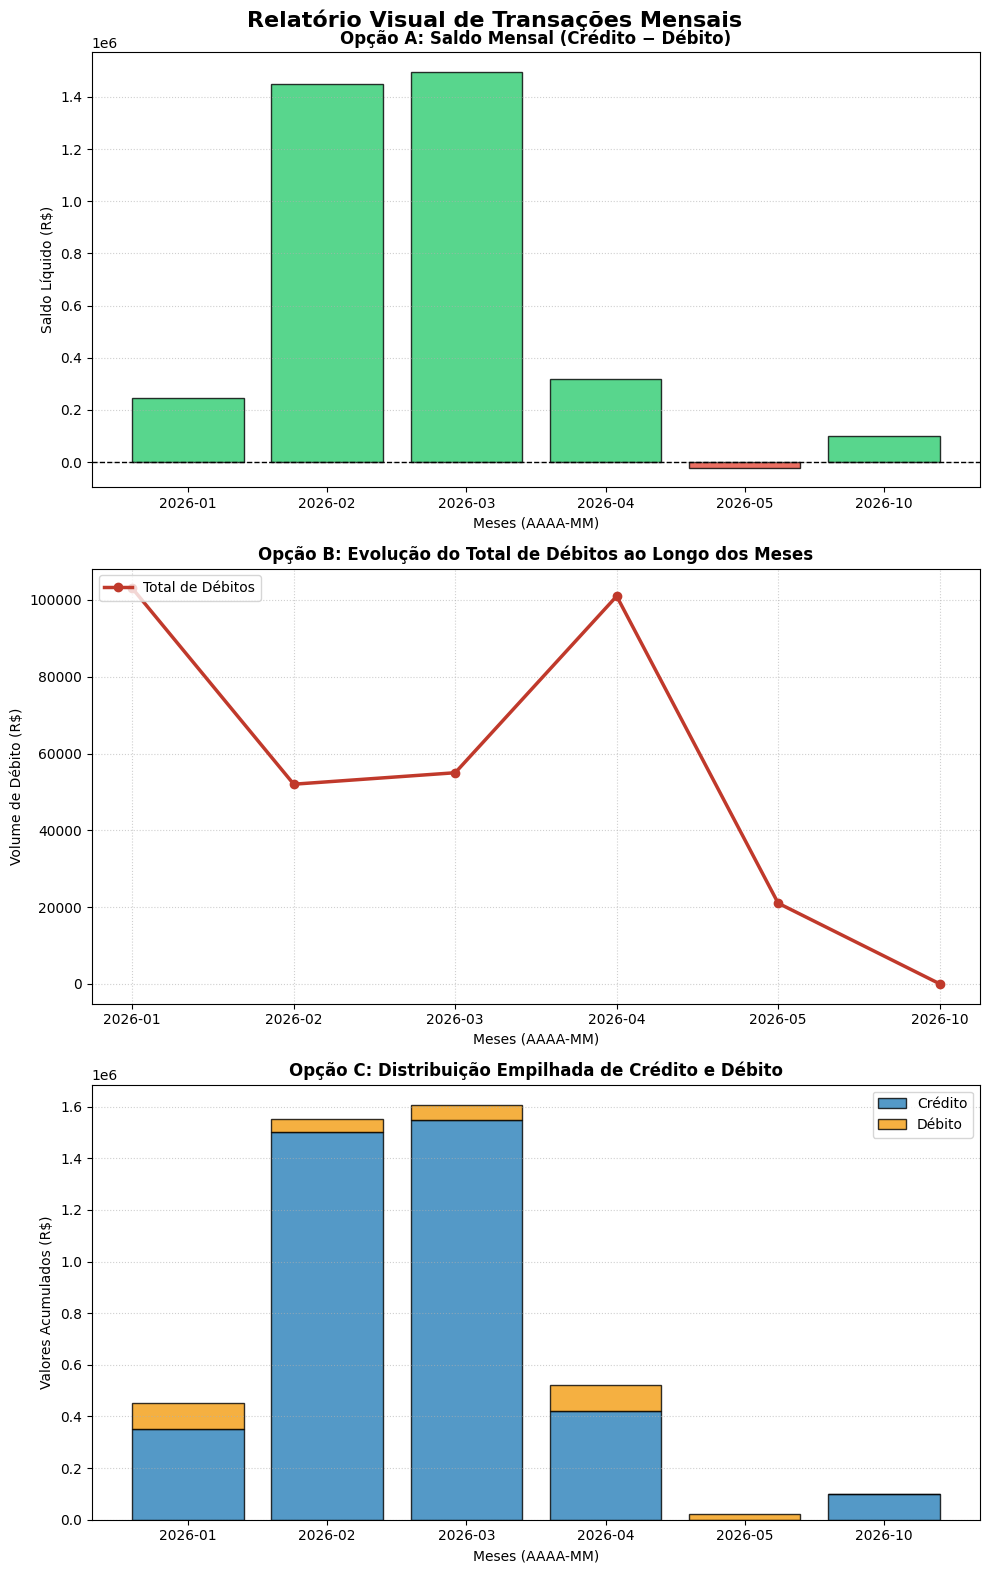

- Total de linhas lidas: [20]
- Linhas válidas: [16]
- Linhas inválidas: [4]

[Sucesso] Arquivo de imagem 'grafico.png' gerado e salvo com sucesso!


In [64]:
# GRÁFICOS

# Verifica se dfDBClear está vazio antes de processar
if dfDBClear.empty:
    print("DataFrame dfDBClear está vazio. Não é possível gerar gráficos.")
else:
    # Garante que a coluna 'data' seja do tipo datetime
    if not pd.api.types.is_datetime64_any_dtype(dfDBClear['data']):
        dfDBClear['data'] = pd.to_datetime(dfDBClear['data'], errors='coerce', dayfirst=True)

    # Garante que a coluna 'ano_mes' exista para agrupamento
    if 'ano_mes' not in dfDBClear.columns:
        # Filtra NaT values before creating 'ano_mes'
        dfDBClear = dfDBClear[dfDBClear['data'].notna()].copy()
        if not dfDBClear.empty:
            dfDBClear['ano_mes'] = dfDBClear['data'].dt.strftime('%Y-%m')
        else:
            print("DataFrame dfDBClear ficou vazio após a remoção de datas inválidas. Não é possível gerar gráficos.")
            exit()

    # Agrupa por mês e calcula a soma separada de créditos e débitos
    df_mensal = dfDBClear.groupby('ano_mes').apply(lambda x: pd.Series({
        'credito': x[x['tipo'] == 'credito']['valor'].sum(),
        'debito': x[x['tipo'] == 'debito']['valor'].sum()
    })).reset_index()

    # Calcula o saldo (Crédito - Débito)
    df_mensal['saldo'] = df_mensal['credito'] - df_mensal['debito']
    df_mensal = df_mensal.sort_values('ano_mes')

    # --- 3. CONSTRUÇÃO DOS GRÁFICOS COM MATPLOTLIB ---

    # Cria uma figura grande contendo 3 subplots verticais (um para cada opção)
    fig, axes = plt.subplots(3, 1, figsize=(10, 16))
    fig.suptitle('Relatório Visual de Transações Mensais', fontsize=16, fontweight='bold', y=0.98)

    # --- Opção A: Gráfico de barras com o saldo mensal
    cores_saldo = ['#2ecc71' if x >= 0 else '#e74c3c' for x in df_mensal['saldo']] # Verde para positivo, vermelho para negativo
    axes[0].bar(df_mensal['ano_mes'], df_mensal['saldo'], color=cores_saldo, edgecolor='black', alpha=0.8)
    axes[0].set_title('Opção A: Saldo Mensal (Crédito − Débito)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Meses (AAAA-MM)', fontsize=10)
    axes[0].set_ylabel('Saldo Líquido (R$)', fontsize=10)
    axes[0].axhline(0, color='black', linewidth=1, linestyle='--') # Linha de referência no zero
    axes[0].grid(axis='y', linestyle=':', alpha=0.6)

    # --- Opção B: Gráfico de linha com a evolução do total de débitos
    axes[1].plot(df_mensal['ano_mes'], df_mensal['debito'], marker='o', color='#c0392b', linewidth=2.5, label='Total de Débitos')
    axes[1].set_title('Opção B: Evolução do Total de Débitos ao Longo dos Meses', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Meses (AAAA-MM)', fontsize=10)
    axes[1].set_ylabel('Volume de Débito (R$)', fontsize=10)
    axes[1].legend(loc='upper left')
    axes[1].grid(True, linestyle=':', alpha=0.6)

    # --- Opção C: Gráfico de barras empilhadas com crédito e débito por mês
    axes[2].bar(df_mensal['ano_mes'], df_mensal['credito'], label='Crédito', color='#2980b9', edgecolor='black', alpha=0.8)
    axes[2].bar(df_mensal['ano_mes'], df_mensal['debito'], bottom=df_mensal['credito'], label='Débito', color='#f39c12', edgecolor='black', alpha=0.8)
    axes[2].set_title('Opção C: Distribuição Empilhada de Crédito e Débito', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Meses (AAAA-MM)', fontsize=10)
    axes[2].set_ylabel('Valores Acumulados (R$)', fontsize=10)
    axes[2].legend(loc='upper right')
    axes[2].grid(axis='y', linestyle=':', alpha=0.6)

    # Ajusta o espaçamento para os elementos não se sobreporem
    plt.tight_layout()

    # --- 4. SALVAMENTO DA IMAGEM E EXIBIÇÃO NO TERMINAL ---
    caminho_imagem = 'grafico.png'
    plt.savefig(caminho_imagem, dpi=300, bbox_inches='tight')
    plt.show()

    # Imprime o resumo da limpeza exigido nas etapas anteriores
    # total_linhas_lidas deve ser definido em uma célula anterior, se não estiver, pode causar um NameError
    if 'total_linhas_lidas' in globals():
        print(f"- Total de linhas lidas: [{total_linhas_lidas}]")
    else:
        print("- Total de linhas lidas: [Não disponível (variável total_linhas_lidas não encontrada)]")

    print(f"- Linhas válidas: [{len(dfDBClear)}]")
    print(f"- Linhas inválidas: [{total_linhas_lidas - len(dfDBClear) if 'total_linhas_lidas' in globals() else 'N/A'}]")
    print(f"\n[Sucesso] Arquivo de imagem '{caminho_imagem}' gerado e salvo com sucesso!")

    # A coluna 'ano_mes' não será removida aqui para garantir sua persistência para outras células
    # dfDBClear = dfDBClear.drop(columns=['ano_mes']) # Esta linha permanece comentada/removida

In [ ]:
display(dfBdD.head())

,id,data,cliente_id,tipo,valor,descricao,categoria
0,1,05/01/2026,CLI001,credito,3500.00,Salário janeiro,salario
1,2,12/01/2026,CLI002,debito,180.50,Supermercado,compra
2,3,20/01/2026,CLI001,debito,850.00,Farmácia,saude
3,4,03/02/2026,CLI004,debito,200.00,Transferência entre contas,transferencia
4,5,14/02/2026,CLI003,credito,15000.00,Transferência empresarial,transferencia


--------------------------------------

# **Código do checklist do projeto**

**1) roda o código do início ao fim**







--- Inicialização: Bibliotecas carregadas ---
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Drive montado. Caminho do arquivo: /content/drive/MyDrive/Datasets/Projeto/transacoes.csv ---

--- Leitura do CSV para dfBdD ---
Informações do DataFrame dfBdD:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          20 non-null     int64 
 1   data        20 non-null     object
 2   cliente_id  19 non-null     object
 3   tipo        20 non-null     object
 4   valor       20 non-null     object
 5   descricao   20 non-null     object
 6   categoria   20 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.2+ KB


None


Primeiras 5 linhas de dfBdD após carregamento:


,id,data,cliente_id,tipo,valor,descricao,categoria
0,1,05/01/2026,CLI001,credito,3500.00,Salário janeiro,salario
1,2,12/01/2026,CLI002,debito,180.50,Supermercado,compra
2,3,20/01/2026,CLI001,debito,850.00,Farmácia,saude
3,4,03/02/2026,CLI004,debito,200.00,Transferência entre contas,transferencia
4,5,14/02/2026,CLI003,credito,15000.00,Transferência empresarial,transferencia



--- Etapa de Limpeza e Validação de Dados para dfDBClear ---
- Total de linhas lidas: [20]
- Linhas válidas: [16]
- Linhas inválidas: [4]

--- Análise de Tempo (Date & Time) ---
- Transação mais antiga encontrada: 2026-01-05
- Transação mais recente encontrada: 2026-10-13
- Dias decorridos entre a primeira e última transação: [281 dias]

===== RELATÓRIO MENSAL =====

Mês: [2026-01]
  Transações: [3]
  Total crédito: [R$ 350000,00]
  Total débito:  [R$ 103050,00]
  Saldo:         [R$ 246950,00]
  Média:         [R$ 151016,67]
  Maior valor:   [R$ 350000,00]
  Menor valor:   [R$ 18050,00]

Mês: [2026-02]
  Transações: [3]
  Total crédito: [R$ 1500000,00]
  Total débito:  [R$ 52000,00]
  Saldo:         [R$ 1448000,00]
  Média:         [R$ 517333,33]
  Maior valor:   [R$ 1500000,00]
  Menor valor:   [R$ 20000,00]

Mês: [2026-03]
  Transações: [4]
  Total crédito: [R$ 1550000,00]
  Total débito:  [R$ 54990,00]
  Saldo:         [R$ 1495010,00]
  Média:         [R$ 401247,50]
  Maior valor: 

/tmp/ipykernel_4940/2379732288.py:232: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_mensal = dfDBClear.groupby('ano_mes').apply(lambda x: pd.Series({


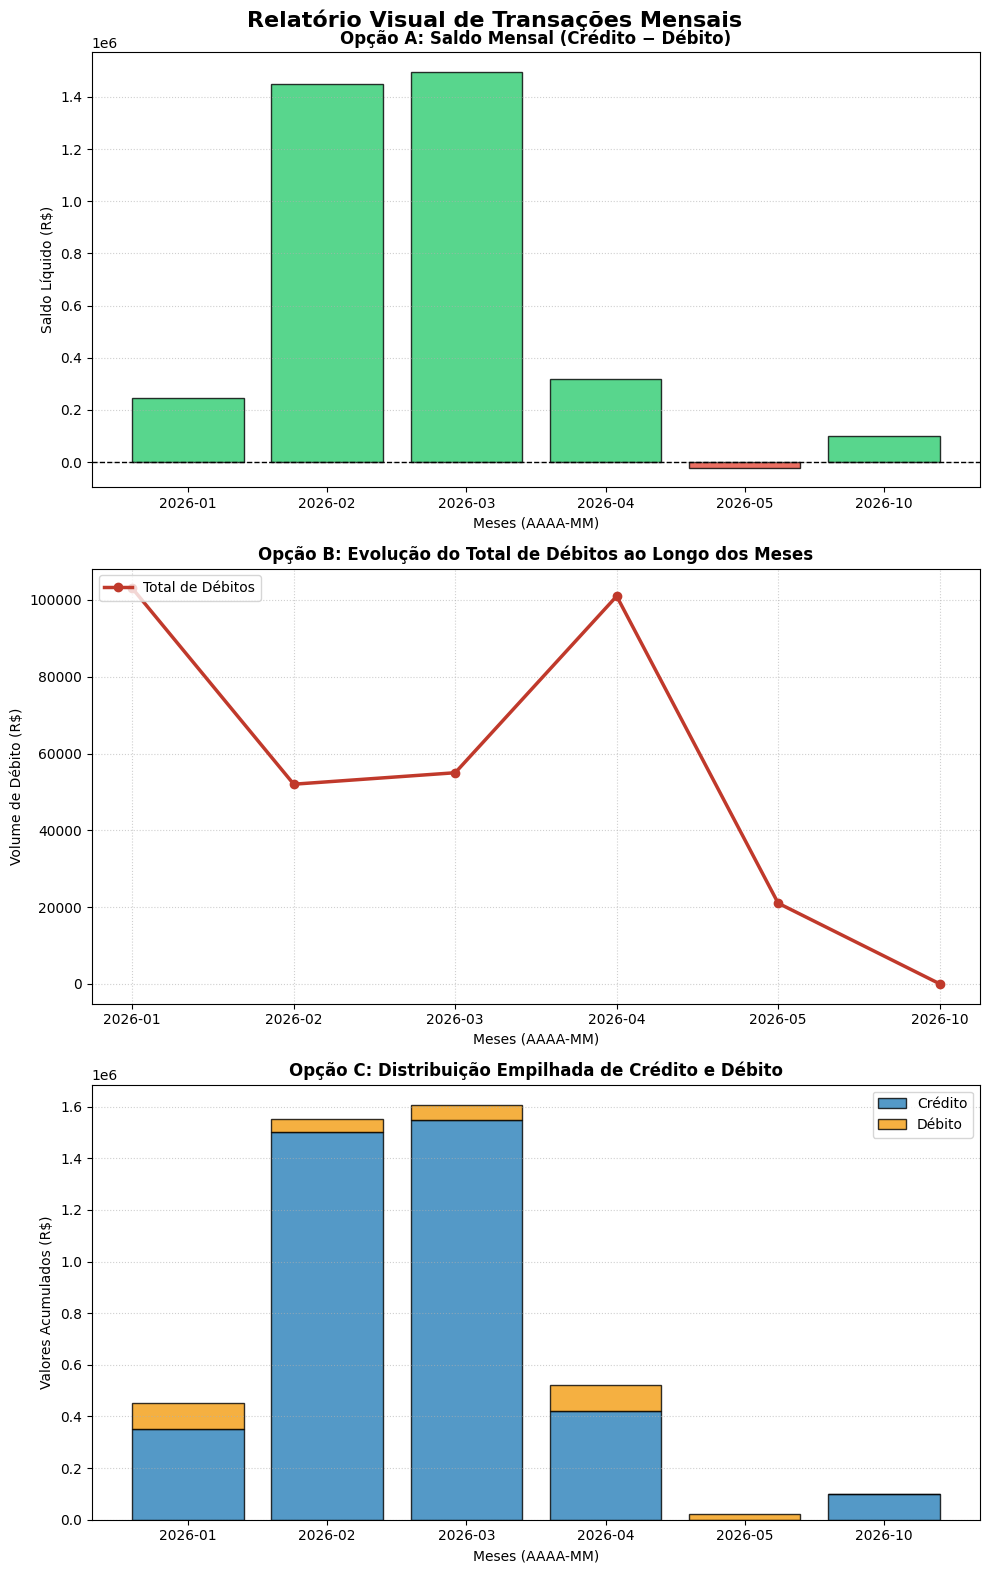


[Sucesso] Arquivo de imagem 'grafico.png' gerado e salvo com sucesso!

--- FIM DO PROCESSAMENTO --- 


In [65]:
# --- 1. Importação de Bibliotecas Necessárias ---
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import csv
import json
from datetime import datetime
import numpy as np # Necessário para pd.isna

print("--- Inicialização: Bibliotecas carregadas ---")

# --- 2. Montagem do Google Drive e Definição do Caminho do Arquivo ---
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/Datasets/Projeto/transacoes.csv'

print(f"--- Drive montado. Caminho do arquivo: {file_path} ---")

# --- 3. Leitura do CSV e Carregamento Inicial no dfBdD ---
# Realiza a leitura do arquivo CSV diretamente para dfBdD, com separador ponto e vírgula
dfBdD = pd.read_csv(file_path, sep=';')

print("\n--- Leitura do CSV para dfBdD ---")
print("Informações do DataFrame dfBdD:")
display(dfBdD.info())
print("\nPrimeiras 5 linhas de dfBdD após carregamento:")
display(dfBdD.head())

# --- 4. Funções Auxiliares para Limpeza e Validação (da célula Y8cd7gQbemNu) ---
def converter_com_strptime(texto_data):
    texto_data_str = str(texto_data).strip()
    # Use pandas to_datetime which is more robust for various formats
    # dayfirst=True to handle DD/MM/YYYY format
    # errors='coerce' to turn unparseable dates into NaT
    return pd.to_datetime(texto_data_str, errors='coerce', dayfirst=True)

print("\n--- Etapa de Limpeza e Validação de Dados para dfDBClear ---")
# 1. Guarda o total de linhas brutas
total_linhas_lidas = len(dfBdD)

# 2. Faz uma cópia para processamento e aplica o strptime para converter texto em objeto datetime
df_processamento = dfBdD.copy()
df_processamento['data_convertida'] = df_processamento['data'].apply(converter_com_strptime)

# 3. Definição dos filtros de limpeza (Garantindo que apenas dados íntegros entrem no dfDBClear)
id_numerico = pd.to_numeric(df_processamento['id'], errors='coerce')
# Ajusta pd.to_numeric para considerar vírgula como separador decimal
valor_numerico = pd.to_numeric(df_processamento['valor'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False), errors='coerce')

mask_valida = (
    df_processamento['data_convertida'].notna() &
    id_numerico.notna() &
    df_processamento['cliente_id'].notna() & (df_processamento['cliente_id'].astype(str).str.strip() != '') &
    df_processamento['tipo'].astype(str).str.strip().str.lower().isin(['credito', 'debito']) &
    valor_numerico.notna() & (valor_numerico > 0)
)

# 4. Criação do DataFrame limpo [dfDBClear]
dfDBClear = df_processamento[mask_valida].copy()

# Substitui a coluna 'data' antiga pelo objeto datetime e remove a coluna temporária
dfDBClear['data'] = dfDBClear['data_convertida']
dfDBClear = dfDBClear.drop(columns=['data_convertida'])

# Atribui os valores numéricos convertidos para a coluna 'valor' no dfDBClear
dfDBClear['valor'] = valor_numerico[mask_valida]

# 5. Extração do mês de cada transação no formato AAAA-MM
dfDBClear['ano_mes'] = dfDBClear['data'].dt.strftime('%Y-%m')

# 6. Cálculo do intervalo de dias entre a transação mais antiga e a mais recente
data_mais_antiga = dfDBClear['data'].min()
data_mais_recente = dfDBClear['data'].max()
dias_passados = (data_mais_recente - data_mais_antiga).days

# 7. Resumos e Métricas para exibição
linhas_validas = len(dfDBClear)
linhas_invalidas = total_linhas_lidas - linhas_validas

# --- Saída Esperada no Terminal ---
print(f"- Total de linhas lidas: [{total_linhas_lidas}]")
print(f"- Linhas válidas: [{linhas_validas}]")
print(f"- Linhas inválidas: [{linhas_invalidas}]")

print("\n--- Análise de Tempo (Date & Time) ---")
# Ensure data_mais_antiga and data_mais_recente are not NaT before calling strftime
if pd.isna(data_mais_antiga):
    print(f"- Transação mais antiga encontrada: Não disponível (nenhum dado válido)")
else:
    print(f"- Transação mais antiga encontrada: {data_mais_antiga.strftime('%Y-%m-%d')}")

if pd.isna(data_mais_recente):
    print(f"- Transação mais recente encontrada: Não disponível (nenhum dado válido)")
else:
    print(f"- Transação mais recente encontrada: {data_mais_recente.strftime('%Y-%m-%d')}")

if pd.isna(dias_passados):
    print(f"- Dias decorridos entre a primeira e última transação: Não disponível (nenhum dado válido)")
else:
    print(f"- Dias decorridos entre a primeira e última transação: [{int(dias_passados)} dias]")

# --- 5. Agrupamento mensal e métricas (da célula bBECYpNATZ7x) ---
print("\n===== RELATÓRIO MENSAL =====")

# Função auxiliar para formatar os valores monetários no padrão PT-BR (R$ 0,00)
def formatar_br(valor):
    return f"R$ {valor:.2f}".replace('.', ',')

# Verifica se dfDBClear está vazio para evitar erros antes do loop
if dfDBClear.empty:
    print("DataFrame dfDBClear está vazio. Não é possível gerar relatório mensal.")
else:
    # Loop (Estrutura de Repetição) que percorre cada mês único de forma cronológica
    for mes in sorted(dfDBClear['ano_mes'].unique()):
        # Filtra o DataFrame apenas com os registros pertencentes ao mês atual da iteração
        df_mes = dfDBClear[dfDBClear['ano_mes'] == mes]

        # Cálculos das métricas solicitadas
        qtd_transacoes = len(df_mes)
        total_credito = df_mes[df_mes['tipo'] == 'credito']['valor'].sum()
        total_debito = df_mes[df_mes['tipo'] == 'debito']['valor'].sum()
        saldo_mes = total_credito - total_debito
        valor_medio = df_mes['valor'].mean() if qtd_transacoes > 0 else 0.0
        maior_valor = df_mes['valor'].max() if qtd_transacoes > 0 else 0.0
        menor_valor = df_mes['valor'].min() if qtd_transacoes > 0 else 0.0

        # Exibição dos dados no terminal seguindo estritamente o modelo de saída esperado
        print(f"\nMês: [{mes}]")
        print(f"  Transações: [{qtd_transacoes}]")
        print(f"  Total crédito: [{formatar_br(total_credito)}]")
        print(f"  Total débito:  [{formatar_br(total_debito)}]")
        print(f"  Saldo:         [{formatar_br(saldo_mes)}]")
        print(f"  Média:         [{formatar_br(valor_medio)}]")
        print(f"  Maior valor:   [{formatar_br(maior_valor)}]")
        print(f"  Menor valor:   [{formatar_br(menor_valor)}]")

# --- 6. Identificação de transações suspeitas (da célula 3tAJHkJl5oQG) ---
LIMITE_SUSPEITO = 10000.00

print("\n===== TRANSAÇÕES SUSPEITAS =====")

if dfDBClear.empty:
    print("DataFrame dfDBClear está vazio. Não é possível identificar transações suspeitas.")
else:
    # Varre o DataFrame limpo utilizando uma estrutura de repetição e condicional
    for index, linha in dfDBClear.iterrows():
        # Estrutura condicional: Verifica se o valor ultrapassa o limite suspeito definido
        if linha['valor'] > LIMITE_SUSPEITO:
            # Formata o valor no padrão monetário para exibição limpa
            valor_formatado = f"R$ {linha['valor']:.2f}".replace('.', ',')

            # Exibe os dados no terminal seguindo estritamente o modelo de saída esperado
            print(f"ID: [{linha['id']}] | Cliente: [{linha['cliente_id']}] | Data: [{linha['data'].strftime('%Y-%m-%d')}] | Valor: [{valor_formatado}]")

# --- 7. Exportação do relatório em JSON (da célula dMkMrXuk8vhO) ---
print("\n--- Exportação do Relatório em JSON ---")

# Verifica se dfDBClear está vazio antes de tentar criar 'ano_mes' ou agrupar
if dfDBClear.empty:
    print("\n[Aviso] dfDBClear está vazio. Não é possível gerar relatório mensal ou criar a coluna 'ano_mes' para JSON.")
    resumo_mensal = {}
else:
    resumo_mensal = {}

    # Percorre cada mês único para extrair os dados financeiros
    for mes in sorted(dfDBClear['ano_mes'].unique()):
        df_mes = dfDBClear[dfDBClear['ano_mes'] == mes]

        qtd = len(df_mes)
        total_credito = df_mes[df_mes['tipo'] == 'credito']['valor'].sum()
        total_debito = df_mes[df_mes['tipo'] == 'debito']['valor'].sum()
        saldo = total_credito - total_debito

        # Monta o dicionário convertendo para tipos nativos do Python (evita erro de serialização do NumPy)
        resumo_mensal[mes] = {
            "quantidade": int(qtd),
            "total_credito": round(float(total_credito), 2),
            "total_debito": round(float(total_debito), 2),
            "saldo": round(float(saldo), 2)
        }

# Montagem final da estrutura do arquivo JSON
json_output_path = 'relatorio.json'

relatorio_final = {
    "gerado_em": datetime.now().strftime('%Y-%m-%d'),
    "total_transacoes_validas": len(dfDBClear),
    "total_transacoes_invalidas": total_linhas_lidas - len(dfDBClear),
    "resumo_mensal": resumo_mensal
}

# Salvamento físico do arquivo JSON
caminho_json = 'relatorio.json'
with open(caminho_json, mode='w', encoding='utf-8') as arquivo_json:
    json.dump(relatorio_final, arquivo_json, indent=4, ensure_ascii=False)

# Exibição do resumo no terminal
print(f"- Total de linhas lidas: [{total_linhas_lidas}]")
print(f"- Linhas válidas: [{len(dfDBClear)}]")
print(f"- Linhas inválidas: [{total_linhas_lidas - len(dfDBClear)}]")
print(f"\n[Sucesso] Arquivo '{caminho_json}' gerado com a estrutura solicitada!")

# Imprime o relatório JSON na tela
print("\n--- Relatório JSON Completo ---")
print(json.dumps(relatorio_final, indent=4, ensure_ascii=False))

# --- 8. Visualização com matplotlib (da célula bEj1wLrJi_1F) ---
print("\n--- Geração dos Gráficos ---")

# Verifica se dfDBClear está vazio antes de processar
if dfDBClear.empty:
    print("DataFrame dfDBClear está vazio. Não é possível gerar gráficos.")
else:
    # Garante que a coluna 'data' seja do tipo datetime (já deveria ser, mas defensivamente)
    if not pd.api.types.is_datetime64_any_dtype(dfDBClear['data']):
        dfDBClear['data'] = pd.to_datetime(dfDBClear['data'], errors='coerce', dayfirst=True)

    # Garante que a coluna 'ano_mes' exista para agrupamento (já deveria ser, mas defensivamente)
    if 'ano_mes' not in dfDBClear.columns:
        # Filtra NaT values before creating 'ano_mes'
        dfDBClear_temp = dfDBClear[dfDBClear['data'].notna()].copy()
        if not dfDBClear_temp.empty:
            dfDBClear_temp['ano_mes'] = dfDBClear_temp['data'].dt.strftime('%Y-%m')
            df_mensal = dfDBClear_temp.groupby('ano_mes').apply(lambda x: pd.Series({
                'credito': x[x['tipo'] == 'credito']['valor'].sum(),
                'debito': x[x['tipo'] == 'debito']['valor'].sum()
            })).reset_index()
        else:
            print("DataFrame dfDBClear ficou vazio após a remoção de datas inválidas. Não é possível gerar gráficos.")
            df_mensal = pd.DataFrame() # Cria um DataFrame vazio para evitar erros
    else:
        # Agrupa por mês e calcula a soma separada de créditos e débitos
        df_mensal = dfDBClear.groupby('ano_mes').apply(lambda x: pd.Series({
            'credito': x[x['tipo'] == 'credito']['valor'].sum(),
            'debito': x[x['tipo'] == 'debito']['valor'].sum()
        })).reset_index()

    if not df_mensal.empty:
        # Calcula o saldo (Crédito - Débito)
        df_mensal['saldo'] = df_mensal['credito'] - df_mensal['debito']
        df_mensal = df_mensal.sort_values('ano_mes')

        # --- 3. CONSTRUÇÃO DOS GRÁFICOS COM MATPLOTLIB ---
        # Cria uma figura grande contendo 3 subplots verticais (um para cada opção)
        fig, axes = plt.subplots(3, 1, figsize=(10, 16))
        fig.suptitle('Relatório Visual de Transações Mensais', fontsize=16, fontweight='bold', y=0.98)

        # --- Opção A: Gráfico de barras com o saldo mensal
        cores_saldo = ['#2ecc71' if x >= 0 else '#e74c3c' for x in df_mensal['saldo']] # Verde para positivo, vermelho para negativo
        axes[0].bar(df_mensal['ano_mes'], df_mensal['saldo'], color=cores_saldo, edgecolor='black', alpha=0.8)
        axes[0].set_title('Opção A: Saldo Mensal (Crédito − Débito)', fontsize=12, fontweight='bold')
        axes[0].set_xlabel('Meses (AAAA-MM)', fontsize=10)
        axes[0].set_ylabel('Saldo Líquido (R$)', fontsize=10)
        axes[0].axhline(0, color='black', linewidth=1, linestyle='--') # Linha de referência no zero
        axes[0].grid(axis='y', linestyle=':', alpha=0.6)

        # --- Opção B: Gráfico de linha com a evolução do total de débitos
        axes[1].plot(df_mensal['ano_mes'], df_mensal['debito'], marker='o', color='#c0392b', linewidth=2.5, label='Total de Débitos')
        axes[1].set_title('Opção B: Evolução do Total de Débitos ao Longo dos Meses', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Meses (AAAA-MM)', fontsize=10)
        axes[1].set_ylabel('Volume de Débito (R$)', fontsize=10)
        axes[1].legend(loc='upper left')
        axes[1].grid(True, linestyle=':', alpha=0.6)

        # --- Opção C: Gráfico de barras empilhadas com crédito e débito por mês
        axes[2].bar(df_mensal['ano_mes'], df_mensal['credito'], label='Crédito', color='#2980b9', edgecolor='black', alpha=0.8)
        axes[2].bar(df_mensal['ano_mes'], df_mensal['debito'], bottom=df_mensal['credito'], label='Débito', color='#f39c12', edgecolor='black', alpha=0.8)
        axes[2].set_title('Opção C: Distribuição Empilhada de Crédito e Débito', fontsize=12, fontweight='bold')
        axes[2].set_xlabel('Meses (AAAA-MM)', fontsize=10)
        axes[2].set_ylabel('Valores Acumulados (R$)', fontsize=10)
        axes[2].legend(loc='upper right')
        axes[2].grid(axis='y', linestyle=':', alpha=0.6)

        # Ajusta o espaçamento para os elementos não se sobreporem
        plt.tight_layout()

        # --- 4. SALVAMENTO DA IMAGEM E EXIBIÇÃO NO TERMINAL ---
        caminho_imagem = 'grafico.png'
        plt.savefig(caminho_imagem, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"\n[Sucesso] Arquivo de imagem '{caminho_imagem}' gerado e salvo com sucesso!")
    else:
        print("Não há dados suficientes em df_mensal para gerar os gráficos.")

print("\n--- FIM DO PROCESSAMENTO --- ")

**2) Testa e valida 4 funções com responsabilidades separadas**

In [66]:
# --- Testes e Validação de Funções Separadas ---

def ler_transacoes(caminho_csv):
    """
    Responsabilidade: Ler o CSV nativamente e retornar uma lista de transações brutas.
    """
    transacoes_brutas = []
    try:
        with open(caminho_csv, mode='r', encoding='utf-8') as arquivo:
            leitor = csv.DictReader(arquivo, delimiter=';') # Adicionado delimiter=';' para consistência
            for linha in leitor:
                transacoes_brutas.append(linha)
    except FileNotFoundError:
        print(f"Erro: O arquivo no caminho '{caminho_csv}' não foi encontrado.")
    return transacoes_brutas


def validar_transacao(linha):
    """
    Responsabilidade: Valida uma única linha (dicionário).
    Retorna o registro limpo/tipado se válido, ou None se for inválido.
    """
    # 1. Validação do ID (Não vazio e numérico)
    id_val = linha.get('id', '').strip()
    if not id_val or not id_val.isdigit():
        return None

    # 2. Validação do cliente_id (Não vazio)
    cliente_id = linha.get('cliente_id', '').strip()
    if not cliente_id:
        return None

    # 3. Validação da Data (Formato estrito AAAA-MM-DD)
    data_val = linha.get('data', '').strip()
    try:
        datetime.strptime(data_val, '%Y-%m-%d')
    except ValueError:
        return None

    # 4. Validação do Tipo ('credito' ou 'debito')
    tipo_val = linha.get('tipo', '').strip().lower()
    if tipo_val not in ['credito', 'debito']:
        return None

    # 5. Validação do Valor (Numérico e maior que zero)
    valor_val = linha.get('valor', '').strip()
    try:
        # Adaptação para formato com vírgula como separador decimal, se necessário
        valor_num = float(valor_val.replace('.', '').replace(',', '.')) # Remove ponto de milhar e troca vírgula por ponto
        if valor_num <= 0:
            return None
    except ValueError:
        return None

    # Se passou em todas as validações, retorna o dicionário com os tipos corrigidos
    return {
        "id": int(id_val),
        "cliente_id": cliente_id,
        "data": data_val,
        "tipo": tipo_val,
        "valor": valor_num
    }


def gerar_relatorio(transacoes_validas, total_lidas):
    """
    Responsabilidade: Agrupar os dados limpos e calcular as métricas gerais e financeiras.
    """
    total_validas = len(transacoes_validas)
    total_invalidas = total_lidas - total_validas

    # Exemplo de agrupamento/métrica extra: soma por tipo de transação
    total_credito = sum(t['valor'] for t in transacoes_validas if t['tipo'] == 'credito')
    total_debito = sum(t['valor'] for t in transacoes_validas if t['tipo'] == 'debito')

    relatorio = {
        "total_linhas_lidas": total_lidas,
        "linhas_validas": total_validas,
        "linhas_invalidas": total_invalidas,
        "agrupamentos": {
            "total_valor_credito": round(total_credito, 2),
            "total_valor_debito": round(total_debito, 2)
        }
    }
    return relatorio


def exibir_relatorio(relatorio):
    """
    Responsabilidade: Formatar e imprimir estritamente os resultados solicitados no terminal.
    """
    print("\n--- Resumo do Relatório (Função exibir_relatorio) ---")
    print(f"- Total de linhas lidas: [{relatorio['total_linhas_lidas']}]")
    print(f"- Linhas válidas: [{relatorio['linhas_validas']}]")
    print(f"- Linhas inválidas: [{relatorio['linhas_invalidas']}]")



# --- Testando as Funções Individualmente ---

print("\n===== Teste da função ler_transacoes =====")
transacoes_brutas_teste = ler_transacoes(FILE_PATH)
if transacoes_brutas_teste:
    print(f"Total de transações brutas lidas: {len(transacoes_brutas_teste)}")
    print("Primeiras 2 transações brutas:")
    for i in range(min(2, len(transacoes_brutas_teste))):
        print(transacoes_brutas_teste[i])
else:
    print("Nenhuma transação bruta lida ou erro no caminho do arquivo.")

print("\n===== Teste da função validar_transacao =====")
# Caso de teste 1: Transação válida
transacao_valida_exemplo = {
    'id': '1', 'data': '2026-01-05', 'cliente_id': 'CLI001',
    'tipo': 'credito', 'valor': '3500.00', 'descricao': 'Salário',
    'categoria': 'salario'
}
resultado_valido = validar_transacao(transacao_valida_exemplo)
print(f"Exemplo Válido: {transacao_valida_exemplo} -> {'Válido' if resultado_valido else 'Inválido'}")
if resultado_valido: print(f"  Dados limpos: {resultado_valido}")

# Caso de teste 2: Transação inválida (valor não numérico)
transacao_invalida_valor = {
    'id': '3', 'data': '2026-01-20', 'cliente_id': 'CLI001',
    'tipo': 'debito', 'valor': 'abc', 'descricao': 'Erro de sistema',
    'categoria': 'compra'
}
resultado_invalido_valor = validar_transacao(transacao_invalida_valor)
print(f"Exemplo Inválido (valor): {transacao_invalida_valor} -> {'Válido' if resultado_invalido_valor else 'Inválido'}")

# Caso de teste 3: Transação inválida (data inválida)
transacao_invalida_data = {
    'id': '10', 'data': '30/02/2026', 'cliente_id': 'CLI002',
    'tipo': 'credito', 'valor': '1200.00', 'descricao': 'Bônus',
    'categoria': 'extra'
}
resultado_invalido_data = validar_transacao(transacao_invalida_data)
print(f"Exemplo Inválido (data): {transacao_invalida_data} -> {'Válido' if resultado_invalido_data else 'Inválido'}")

# Preparar transações válidas para o próximo teste
transacoes_validas_teste = []
for transacao_bruta in transacoes_brutas_teste:
    transacao_limpa = validar_transacao(transacao_bruta)
    if transacao_limpa:
        transacoes_validas_teste.append(transacao_limpa)

print("\n===== Teste da função gerar_relatorio =====")
total_lidas_teste = len(transacoes_brutas_teste)
relatorio_teste = gerar_relatorio(transacoes_validas_teste, total_lidas_teste)
print("Relatório gerado:")
print(json.dumps(relatorio_teste, indent=4))

print("\n===== Teste da função exibir_relatorio =====")
exibir_relatorio(relatorio_teste)

print("\n--- Testes de funções concluídos ---")


===== Teste da função ler_transacoes =====
Total de transações brutas lidas: 20
Primeiras 2 transações brutas:
{'id': '1', 'data': '05/01/2026', 'cliente_id': 'CLI001', 'tipo': 'credito', 'valor': '3500.00', 'descricao': 'Salário janeiro', 'categoria': 'salario'}
{'id': '2', 'data': '12/01/2026', 'cliente_id': 'CLI002', 'tipo': 'debito', 'valor': '180.50', 'descricao': 'Supermercado', 'categoria': 'compra'}

===== Teste da função validar_transacao =====
Exemplo Válido: {'id': '1', 'data': '2026-01-05', 'cliente_id': 'CLI001', 'tipo': 'credito', 'valor': '3500.00', 'descricao': 'Salário', 'categoria': 'salario'} -> Válido
  Dados limpos: {'id': 1, 'cliente_id': 'CLI001', 'data': '2026-01-05', 'tipo': 'credito', 'valor': 350000.0}
Exemplo Inválido (valor): {'id': '3', 'data': '2026-01-20', 'cliente_id': 'CLI001', 'tipo': 'debito', 'valor': 'abc', 'descricao': 'Erro de sistema', 'categoria': 'compra'} -> Inválido
Exemplo Inválido (data): {'id': '10', 'data': '30/02/2026', 'cliente_id': '

**3) Testa 3 situações distintas com try/except**

In [67]:
# --- Testando 3 Situações Distintas com try/except ---

print("===== Teste de Tratamento de Erros (try/except) =====\n")

# Situação 1: FileNotFoundError (Arquivo não encontrado)
print("--- Situação 1: Arquivo não encontrado ---")
try:
    with open("arquivo_inexistente.txt", "r") as f:
        conteudo = f.read()
        print(f"Conteúdo do arquivo: {conteudo}")
except FileNotFoundError:
    print("Erro: O arquivo 'arquivo_inexistente.txt' não foi encontrado.")
except Exception as e:
    print(f"Ocorreu um erro inesperado ao tentar abrir o arquivo: {e}")
finally:
    print("Bloco finally executado para a situação 1.\n")


# Situação 2: ValueError (Conversão de tipo inválida)
print("--- Situação 2: Conversão de tipo inválida ---")
texto_numero = "abc"
try:
    numero = int(texto_numero)
    print(f"Número convertido: {numero}")
except ValueError:
    print(f"Erro: Não foi possível converter '{texto_numero}' para um número inteiro. Formato inválido.")
except Exception as e:
    print(f"Ocorreu um erro inesperado ao tentar converter o valor: {e}")
finally:
    print("Bloco finally executado para a situação 2.\n")


# Situação 3: ZeroDivisionError (Divisão por zero)
print("--- Situação 3: Divisão por zero ---")
num1 = 10
num2 = 0
try:
    resultado = num1 / num2
    print(f"Resultado da divisão: {resultado}")
except ZeroDivisionError:
    print("Erro: Não é possível dividir um número por zero.")
except Exception as e:
    print(f"Ocorreu um erro inesperado ao tentar dividir: {e}")
finally:
    print("Bloco finally executado para a situação 3.\n")

print("===== Testes de tratamento de erros concluídos =====")

===== Teste de Tratamento de Erros (try/except) =====

--- Situação 1: Arquivo não encontrado ---
Erro: O arquivo 'arquivo_inexistente.txt' não foi encontrado.
Bloco finally executado para a situação 1.

--- Situação 2: Conversão de tipo inválida ---
Erro: Não foi possível converter 'abc' para um número inteiro. Formato inválido.
Bloco finally executado para a situação 2.

--- Situação 3: Divisão por zero ---
Erro: Não é possível dividir um número por zero.
Bloco finally executado para a situação 3.

===== Testes de tratamento de erros concluídos =====


**4) Gere o arquivo relatorio.json**

In [68]:
# --- Geração do arquivo relatorio.json ---

# As funções e variáveis necessárias (como dfDBClear, total_linhas_lidas)
# já foram definidas e populadas nas células anteriores (Y8cd7gQbemNu, etc.).
# Para garantir a independência deste bloco, vamos redefinir JSON_OUTPUT_PATH
# e a função salvar_json/gerar_relatorio se não estiverem no escopo global,
# mas idealmente elas já estariam disponíveis.

# --- REDEFINIÇÃO DE FUNÇÕES E VARIÁVEIS (se não estiverem disponíveis) ---
# Este bloco defensivo garante que as funções essenciais e variáveis estão disponíveis
# sem depender estritamente da execução em ordem de todas as células anteriores,
# embora o fluxo principal do notebook as defina.

JSON_OUTPUT_PATH = 'relatorio.json'

# Se 'dfDBClear' ou 'total_linhas_lidas' não estiverem no escopo, use os valores do kernel.
if 'dfDBClear' not in globals():
    # Isso é um fallback. Em um fluxo normal, dfDBClear estaria populado.
    # Para este teste, vamos assumir que foi populado ou criar um DataFrame vazio para evitar erros.
    print("[Aviso]: 'dfDBClear' não encontrado no escopo global. Usando um DataFrame vazio para demonstração.")
    dfDBClear = pd.DataFrame(columns=['id', 'data', 'cliente_id', 'tipo', 'valor', 'descricao', 'categoria', 'ano_mes'])

if 'total_linhas_lidas' not in globals():
    total_linhas_lidas = 0 # Fallback


def gerar_relatorio_para_json(transacoes_validas_df, total_lidas):
    """
    Responsabilidade: Agrupar os dados limpos do DataFrame e calcular as métricas gerais e financeiras.
    Retorna um dicionário com o relatório.
    """
    total_validas = len(transacoes_validas_df)
    total_invalidas = total_lidas - total_validas

    resumo_mensal = {}
    if not transacoes_validas_df.empty and 'ano_mes' in transacoes_validas_df.columns:
        for mes in sorted(transacoes_validas_df['ano_mes'].unique()):
            df_mes = transacoes_validas_df[transacoes_validas_df['ano_mes'] == mes]
            qtd = len(df_mes)
            total_credito = df_mes[df_mes['tipo'] == 'credito']['valor'].sum()
            total_debito = df_mes[df_mes['tipo'] == 'debito']['valor'].sum()
            saldo = total_credito - total_debito

            resumo_mensal[mes] = {
                "quantidade": int(qtd),
                "total_credito": round(float(total_credito), 2),
                "total_debito": round(float(total_debito), 2),
                "saldo": round(float(saldo), 2)
            }

    relatorio = {
        "gerado_em": datetime.now().strftime('%Y-%m-%d'),
        "total_transacoes_validas": total_validas,
        "total_transacoes_invalidas": total_invalidas,
        "resumo_mensal": resumo_mensal
    }
    return relatorio


def salvar_json(relatorio_data, caminho_destino):
    """
    Responsabilidade: Salvar o dicionário de relatório no arquivo JSON.
    """
    try:
        with open(caminho_destino, mode='w', encoding='utf-8') as arquivo_json:
            json.dump(relatorio_data, arquivo_json, indent=4, ensure_ascii=False)
        print(f"[Sucesso] Arquivo '{caminho_destino}' gerado com a estrutura solicitada!")
    except Exception as e:
        print(f"[Erro] Não foi possível salvar o arquivo JSON '{caminho_destino}': {e}")

# --- GERAÇÃO E SALVAMENTO DO JSON --- (Re-executa a lógica da célula dMkMrXuk8vhO)

# Gerar o relatório final a partir do dfDBClear atual
relatorio_final_json = gerar_relatorio_para_json(dfDBClear, total_linhas_lidas)

# Salvar o relatório em formato JSON
salvar_json(relatorio_final_json, JSON_OUTPUT_PATH)

# --- CHAMA/EXIBE O RELATÓRIO JSON ---
print("\n===== Chamada do Relatório JSON Salvo =====")
try:
    with open(JSON_OUTPUT_PATH, 'r', encoding='utf-8') as f:
        relatorio_carregado = json.load(f)
    print("Conteúdo do 'relatorio.json':\n")
    print(json.dumps(relatorio_carregado, indent=4, ensure_ascii=False))
except FileNotFoundError:
    print(f"Erro: O arquivo '{JSON_OUTPUT_PATH}' não foi encontrado.")
except json.JSONDecodeError:
    print(f"Erro: Não foi possível decodificar o JSON do arquivo '{JSON_OUTPUT_PATH}'.")
except Exception as e:
    print(f"Ocorreu um erro inesperado ao carregar o relatório JSON: {e}")

[Sucesso] Arquivo 'relatorio.json' gerado com a estrutura solicitada!

===== Chamada do Relatório JSON Salvo =====
Conteúdo do 'relatorio.json':

{
    "gerado_em": "2026-07-18",
    "total_transacoes_validas": 16,
    "total_transacoes_invalidas": 4,
    "resumo_mensal": {
        "2026-01": {
            "quantidade": 3,
            "total_credito": 350000.0,
            "total_debito": 103050.0,
            "saldo": 246950.0
        },
        "2026-02": {
            "quantidade": 3,
            "total_credito": 1500000.0,
            "total_debito": 52000.0,
            "saldo": 1448000.0
        },
        "2026-03": {
            "quantidade": 4,
            "total_credito": 1550000.0,
            "total_debito": 54990.0,
            "saldo": 1495010.0
        },
        "2026-04": {
            "quantidade": 3,
            "total_credito": 420000.0,
            "total_debito": 101000.0,
            "saldo": 319000.0
        },
        "2026-05": {
            "quantidade": 2,
 

**5) gere relatório e exibido no terminal**

In [69]:
# --- Exibir o Relatório JSON Salvo no Terminal ---

import json

JSON_OUTPUT_PATH = 'relatorio.json'

print("\n===== Relatório JSON Exibido no Terminal =====")
try:
    with open(JSON_OUTPUT_PATH, 'r', encoding='utf-8') as f:
        relatorio_carregado = json.load(f)
    print("Conteúdo do 'relatorio.json':\n")
    print(json.dumps(relatorio_carregado, indent=4, ensure_ascii=False))
except FileNotFoundError:
    print(f"Erro: O arquivo '{JSON_OUTPUT_PATH}' não foi encontrado.")
except json.JSONDecodeError:
    print(f"Erro: Não foi possível decodificar o JSON do arquivo '{JSON_OUTPUT_PATH}'.")
except Exception as e:
    print(f"Ocorreu um erro inesperado ao carregar o relatório JSON: {e}")

print("===== Exibição do relatório concluída =====")


===== Relatório JSON Exibido no Terminal =====
Conteúdo do 'relatorio.json':

{
    "gerado_em": "2026-07-18",
    "total_transacoes_validas": 16,
    "total_transacoes_invalidas": 4,
    "resumo_mensal": {
        "2026-01": {
            "quantidade": 3,
            "total_credito": 350000.0,
            "total_debito": 103050.0,
            "saldo": 246950.0
        },
        "2026-02": {
            "quantidade": 3,
            "total_credito": 1500000.0,
            "total_debito": 52000.0,
            "saldo": 1448000.0
        },
        "2026-03": {
            "quantidade": 4,
            "total_credito": 1550000.0,
            "total_debito": 54990.0,
            "saldo": 1495010.0
        },
        "2026-04": {
            "quantidade": 3,
            "total_credito": 420000.0,
            "total_debito": 101000.0,
            "saldo": 319000.0
        },
        "2026-05": {
            "quantidade": 2,
            "total_credito": 0.0,
            "total_debito": 21000.